Library berhasil diimport!
Versi Pandas: 2.3.3
Versi NumPy: 2.2.6
✓ Berhasil load pelanggan: 99,441 baris
✓ Berhasil load pesanan: 99,441 baris
✓ Berhasil load item_pesanan: 112,650 baris
✓ Berhasil load produk: 32,951 baris
✓ Berhasil load penjual: 3,095 baris
✓ Berhasil load ulasan: 99,224 baris
✓ Berhasil load pembayaran: 103,886 baris
✓ Berhasil load kategori_produk: 71 baris

STATUS LOAD DATASET:
Jumlah dataset yang berhasil diload: 8/8
Semua dataset tersedia! Melanjutkan ke tahap pembersihan data...
Penanganan nilai yang hilang pada dataset produk...
Nilai hilang sebelum ditangani: 610
Nilai hilang setelah ditangani: 0

Penghapusan data duplikat...
pelanggan: tidak ada duplikat
pesanan: tidak ada duplikat
item_pesanan: tidak ada duplikat
produk: tidak ada duplikat
penjual: tidak ada duplikat
ulasan: tidak ada duplikat
pembayaran: tidak ada duplikat
kategori_produk: tidak ada duplikat
Menggabungkan dataset...
Bentuk dataset akhir: (118307, 40)
Total baris data: 118,307 baris

Pemb

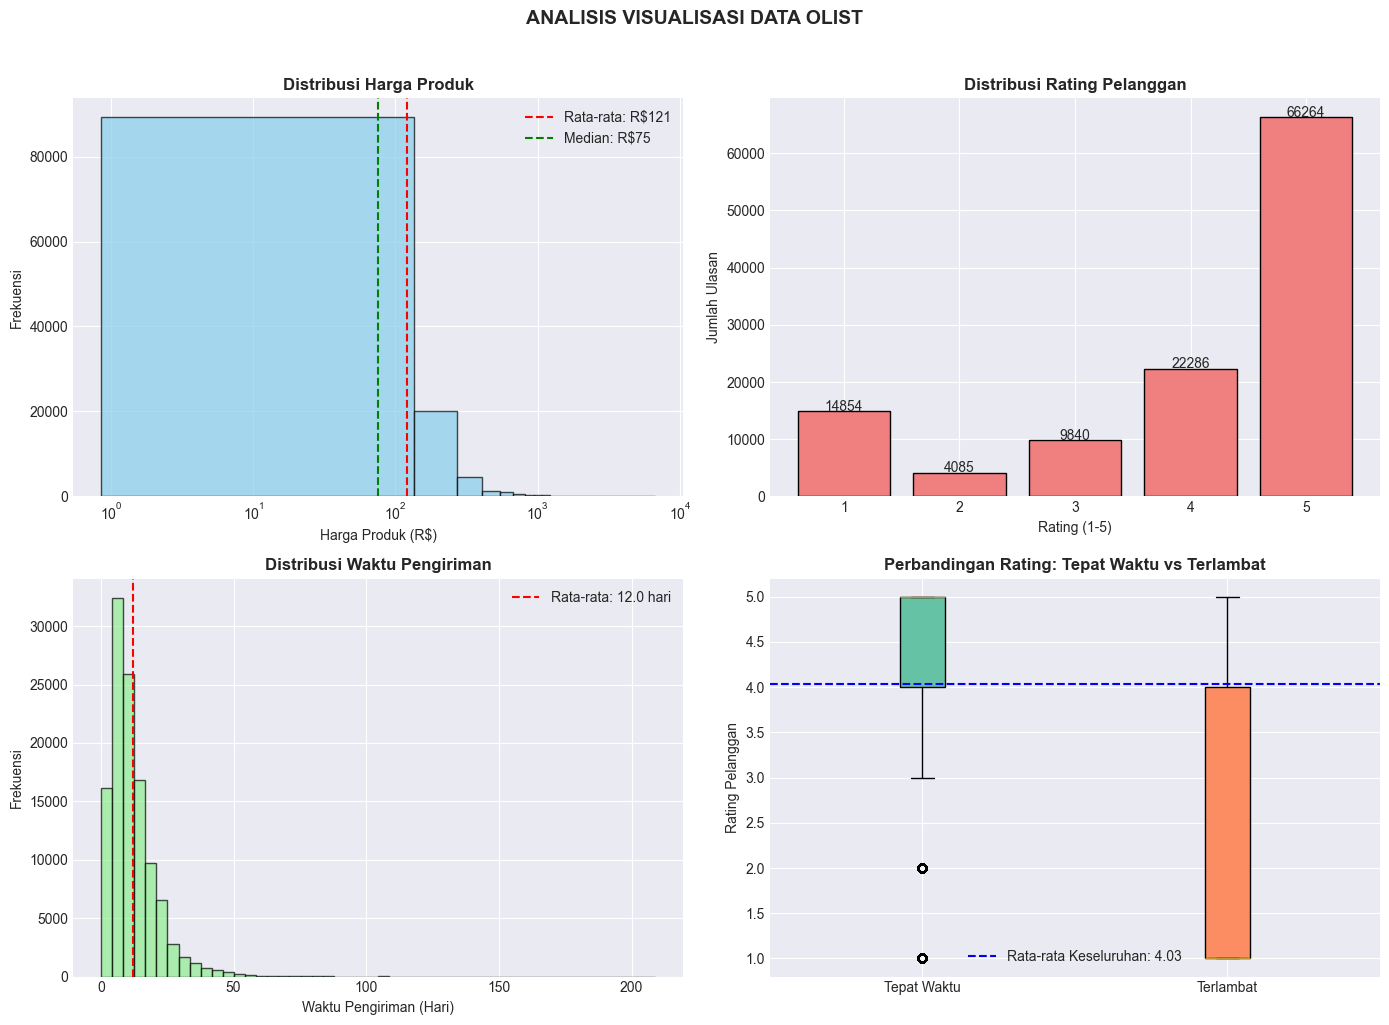

Scatterplot berhasil disimpan di D:/Tugas/scatterplot_pengiriman_rating.png


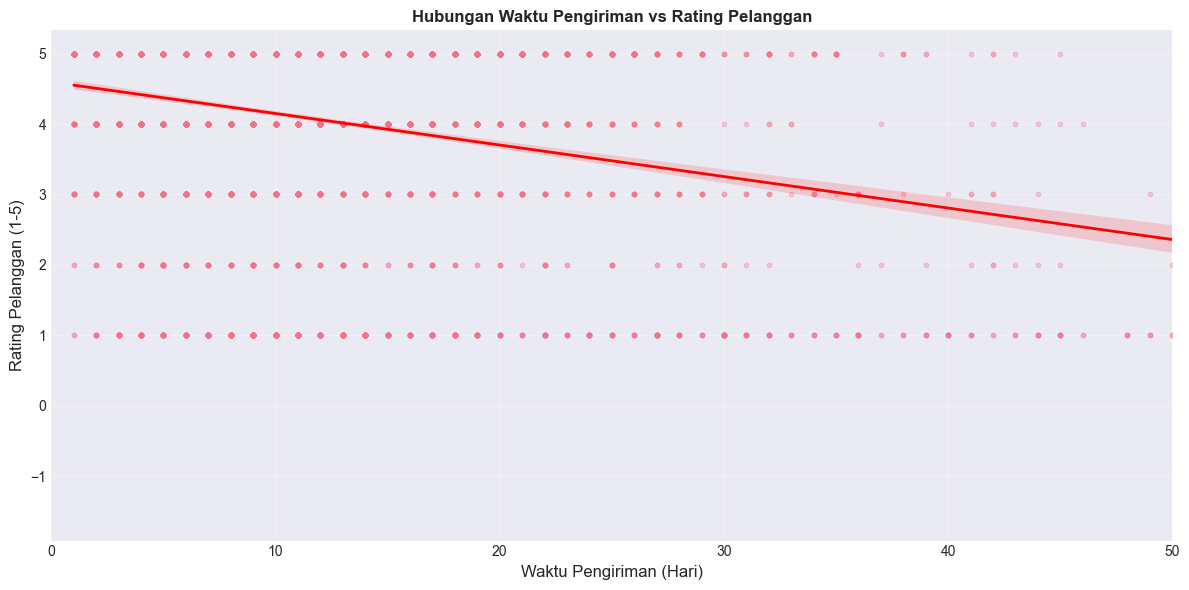

INSIGHT BISNIS & REKOMENDASI STRATEGI

1. PRODUK PALING LAKU (BEST SELLER)
--------------------------------------------------
1. BED_BATH_TABLE
   - Jumlah Terjual: 11,988.0 unit
   - Total Pendapatan: R$ 1,107,249
   - Rata-rata Rating: 3.89/5
2. HEALTH_BEAUTY
   - Jumlah Terjual: 10,029.0 unit
   - Total Pendapatan: R$ 1,301,813
   - Rata-rata Rating: 4.14/5
3. SPORTS_LEISURE
   - Jumlah Terjual: 9,004.0 unit
   - Total Pendapatan: R$ 1,029,604
   - Rata-rata Rating: 4.11/5
4. FURNITURE_DECOR
   - Jumlah Terjual: 8,832.0 unit
   - Total Pendapatan: R$ 772,096
   - Rata-rata Rating: 3.91/5
5. COMPUTERS_ACCESSORIES
   - Jumlah Terjual: 8,150.0 unit
   - Total Pendapatan: R$ 950,054
   - Rata-rata Rating: 3.94/5

2. PRODUK DENGAN RATING TERTINGGI
--------------------------------------------------
1. cds_dvds_musicals: 4.64/5
2. fashion_childrens_clothes: 4.50/5
3. books_general_interest: 4.44/5
4. books_imported: 4.42/5
5. flowers: 4.42/5

3. REKOMENDASI STRATEGI BISNIS
----------------

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis, pearsonr, ttest_ind, f_oneway, chi2_contingency
import warnings
import os

warnings.filterwarnings('ignore')

# Pengaturan style visualisasi
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

print("Library berhasil diimport!")
print(f"Versi Pandas: {pd.__version__}")
print(f"Versi NumPy: {np.__version__}")

lokasi_data = "D:/Tugas"

# Daftar file dataset Olist yang diperlukan
daftar_file = {
    'pelanggan': os.path.join(lokasi_data, 'olist_customers_dataset.csv'),
    'pesanan': os.path.join(lokasi_data, 'olist_orders_dataset.csv'),
    'item_pesanan': os.path.join(lokasi_data, 'olist_order_items_dataset.csv'),
    'produk': os.path.join(lokasi_data, 'olist_products_dataset.csv'),
    'penjual': os.path.join(lokasi_data, 'olist_sellers_dataset.csv'),
    'ulasan': os.path.join(lokasi_data, 'olist_order_reviews_dataset.csv'),
    'pembayaran': os.path.join(lokasi_data, 'olist_order_payments_dataset.csv'),
    'kategori_produk': os.path.join(lokasi_data, 'product_category_name_translation.csv')
}

semua_dataset = {}
for nama, path in daftar_file.items():
    try:
        semua_dataset[nama] = pd.read_csv(path)
        print(f"✓ Berhasil load {nama}: {len(semua_dataset[nama]):,} baris")
    except FileNotFoundError:
        print(f"✗ File tidak ditemukan: {path}")
        print(f"  Pastikan file {nama}.csv ada di folder {lokasi_data}")

# Assign ke variabel terpisah
if 'pelanggan' in semua_dataset:
    pelanggan = semua_dataset['pelanggan']
if 'pesanan' in semua_dataset:
    pesanan = semua_dataset['pesanan']
if 'item_pesanan' in semua_dataset:
    item_pesanan = semua_dataset['item_pesanan']
if 'produk' in semua_dataset:
    produk = semua_dataset['produk']
if 'penjual' in semua_dataset:
    penjual = semua_dataset['penjual']
if 'ulasan' in semua_dataset:
    ulasan = semua_dataset['ulasan']
if 'pembayaran' in semua_dataset:
    pembayaran = semua_dataset['pembayaran']
if 'kategori_produk' in semua_dataset:
    kategori_produk = semua_dataset['kategori_produk']

print("\n" + "="*50)
print("STATUS LOAD DATASET:")
print("="*50)
print(f"Jumlah dataset yang berhasil diload: {len(semua_dataset)}/8")

# Cek dataset yang tersedia
dataset_diperlukan = ['pesanan', 'item_pesanan', 'produk', 'pelanggan', 
                      'penjual', 'ulasan', 'pembayaran', 'kategori_produk']

dataset_hilang = [ds for ds in dataset_diperlukan if ds not in semua_dataset]
if dataset_hilang:
    print("PERINGATAN: Dataset berikut TIDAK DITEMUKAN:")
    for ds in dataset_hilang:
        print(f"  - {ds}.csv")
    print("\nSilakan download semua file dari Kaggle terlebih dahulu!")
    print("Link: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce")
else:
    print("Semua dataset tersedia! Melanjutkan ke tahap pembersihan data...")

# PENANGANAN NILAI YANG HILANG
if 'produk' in semua_dataset:
    print("Penanganan nilai yang hilang pada dataset produk...")
    print(f"Nilai hilang sebelum ditangani: {produk['product_category_name'].isnull().sum()}")
    
    produk['product_category_name'] = produk['product_category_name'].fillna('tidak_diketahui')
    produk['product_weight_g'] = produk['product_weight_g'].fillna(produk['product_weight_g'].median())
    
    for kolom in ['product_length_cm', 'product_height_cm', 'product_width_cm']:
        if kolom in produk.columns:
            produk[kolom] = produk[kolom].fillna(produk[kolom].median())
    
    print(f"Nilai hilang setelah ditangani: {produk['product_category_name'].isnull().sum()}")

if 'pesanan' in semua_dataset:
    kolom_tanggal = ['order_purchase_timestamp', 'order_approved_at', 
                     'order_delivered_carrier_date', 'order_delivered_customer_date', 
                     'order_estimated_delivery_date']
    for kolom in kolom_tanggal:
        if kolom in pesanan.columns:
            pesanan[kolom] = pd.to_datetime(pesanan[kolom], errors='coerce')

# PENGHAPUSAN DATA DUPLIKAT
print("\nPenghapusan data duplikat...")
for nama, df in semua_dataset.items():
    sebelum = len(df)
    semua_dataset[nama] = df.drop_duplicates()
    sesudah = len(semua_dataset[nama])
    if sebelum - sesudah > 0:
        print(f"{nama}: {sebelum - sesudah} duplikat dihapus")
    else:
        print(f"{nama}: tidak ada duplikat")

# Update variabel
if 'pesanan' in semua_dataset:
    pesanan = semua_dataset['pesanan']
if 'item_pesanan' in semua_dataset:
    item_pesanan = semua_dataset['item_pesanan']
if 'produk' in semua_dataset:
    produk = semua_dataset['produk']
if 'pelanggan' in semua_dataset:
    pelanggan = semua_dataset['pelanggan']
if 'ulasan' in semua_dataset:
    ulasan = semua_dataset['ulasan']
if 'pembayaran' in semua_dataset:
    pembayaran = semua_dataset['pembayaran']

# PENGGABUNGAN DATASET
if len(semua_dataset) == 8:
    print("Menggabungkan dataset...")
    data_akhir = pesanan.copy()
    data_akhir = pd.merge(data_akhir, item_pesanan, on='order_id', how='inner')
    data_akhir = pd.merge(data_akhir, produk, on='product_id', how='inner')
    data_akhir = pd.merge(data_akhir, pembayaran, on='order_id', how='inner')
    data_akhir = pd.merge(data_akhir, pelanggan, on='customer_id', how='inner')
    data_akhir = pd.merge(data_akhir, penjual, on='seller_id', how='inner')
    data_akhir = pd.merge(data_akhir, ulasan, on='order_id', how='left')
    data_akhir = pd.merge(data_akhir, kategori_produk, on='product_category_name', how='left')
    
    print(f"Bentuk dataset akhir: {data_akhir.shape}")
    print(f"Total baris data: {len(data_akhir):,} baris")
else:
    print("Tidak dapat melakukan penggabungan karena dataset tidak lengkap!")
    data_akhir = None

# PEMBUATAN FITUR BARU 
if data_akhir is not None:
    print("\nPembuatan fitur baru...")
    
    kolom_tanggal = ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']
    for kolom in kolom_tanggal:
        if kolom in data_akhir.columns:
            data_akhir[kolom] = pd.to_datetime(data_akhir[kolom], errors='coerce')
    
    if 'order_delivered_customer_date' in data_akhir.columns and 'order_purchase_timestamp' in data_akhir.columns:
        data_akhir['lama_pengiriman_hari'] = (data_akhir['order_delivered_customer_date'] - data_akhir['order_purchase_timestamp']).dt.days
    
    if 'order_delivered_customer_date' in data_akhir.columns and 'order_estimated_delivery_date' in data_akhir.columns:
        data_akhir['keterlambatan_pengiriman'] = (data_akhir['order_delivered_customer_date'] - data_akhir['order_estimated_delivery_date']).dt.days
    
    if 'order_purchase_timestamp' in data_akhir.columns:
        data_akhir['bulan_pesanan'] = data_akhir['order_purchase_timestamp'].dt.month
        data_akhir['tahun_pesanan'] = data_akhir['order_purchase_timestamp'].dt.year
    
    if 'price' in data_akhir.columns and 'freight_value' in data_akhir.columns:
        data_akhir['total_nilai_item'] = data_akhir['price'] + data_akhir['freight_value']
    
    print("Pembuatan fitur baru selesai!")

# STATISTIK DESKRIPTIF
if data_akhir is not None:
    print("="*60)
    print("STATISTIK DESKRIPTIF")
    print("="*60)
    
    kolom_numerik = [kol for kol in ['price', 'freight_value', 'review_score', 
                                     'lama_pengiriman_hari', 'payment_value']
                    if kol in data_akhir.columns]
    
    if kolom_numerik:
        print(data_akhir[kolom_numerik].describe())
    
    # Statistik bisnis
    print("\n" + "="*60)
    print("STATISTIK BISNIS UTAMA")
    print("="*60)
    
    if 'price' in data_akhir.columns:
        print(f"Total Pendapatan: R$ {data_akhir['price'].sum():,.0f}")
    
    if 'order_id' in data_akhir.columns:
        print(f"Total Transaksi Unik: {data_akhir['order_id'].nunique():,}")
    
    if 'review_score' in data_akhir.columns:
        print(f"Rata-rata Rating: {data_akhir['review_score'].mean():.2f}/5")
    
    if 'lama_pengiriman_hari' in data_akhir.columns:
        rata_pengiriman = data_akhir['lama_pengiriman_hari'].mean()
        if not pd.isna(rata_pengiriman):
            print(f"Rata-rata Waktu Pengiriman: {rata_pengiriman:.1f} hari")

# UKURAN TENDENSI SENTRAL

if data_akhir is not None:
    print("="*60)
    print("UKURAN TENDENSI SENTRAL")
    print("="*60)
    
    for kolom in ['price', 'review_score', 'lama_pengiriman_hari']:
        if kolom in data_akhir.columns:
            nilai = data_akhir[kolom].dropna()
            if len(nilai) > 0:
                print(f"\n--- {kolom} ---")
                print(f"Rata-rata (Mean): {nilai.mean():.2f}")
                print(f"Nilai Tengah (Median): {nilai.median():.2f}")
                modus = nilai.mode()
                if len(modus) > 0:
                    print(f"Nilai Terbanyak (Modus): {modus.iloc[0]:.2f}")

# VARIABILITAS

if data_akhir is not None:
    print("="*60)
    print("ANALISIS VARIABILITAS")
    print("="*60)
    
    for kolom in ['price', 'review_score', 'lama_pengiriman_hari']:
        if kolom in data_akhir.columns:
            nilai = data_akhir[kolom].dropna()
            if len(nilai) > 0 and nilai.mean() != 0:
                varians = nilai.var()
                std_dev = nilai.std()
                koefisien_variasi = (std_dev / nilai.mean()) * 100
                
                print(f"\n--- {kolom} ---")
                print(f"Varians: {varians:.2f}")
                print(f"Standar Deviasi: {std_dev:.2f}")
                print(f"Koefisien Variasi: {koefisien_variasi:.2f}%")

# SKEWNESS & KURTOSIS

if data_akhir is not None:
    print("="*60)
    print("SKEWNESS & KURTOSIS (KEMIRINGAN & KERUNCINGAN)")
    print("="*60)
    
    for kolom in ['price', 'review_score', 'lama_pengiriman_hari']:
        if kolom in data_akhir.columns:
            nilai = data_akhir[kolom].dropna()
            if len(nilai) > 0:
                kemiringan = skew(nilai)
                keruncingan = kurtosis(nilai)
                
                print(f"\n--- {kolom} ---")
                print(f"Skewness (Kemiringan): {kemiringan:.3f}")
                print(f"Kurtosis (Keruncingan): {keruncingan:.3f}")
                
                # Interpretasi kemiringan
                if kemiringan > 0.5:
                    print("Interpretasi: Miring ke kanan - Banyak nilai kecil")
                elif kemiringan < -0.5:
                    print("Interpretasi: Miring ke kiri - Banyak nilai besar")
                else:
                    print("Interpretasi: Simetris")
                
                # Interpretasi keruncingan
                if keruncingan > 1:
                    print("Interpretasi: Leptokurtic - Distribusi sangat runcing")
                elif keruncingan < -1:
                    print("Interpretasi: Platykurtic - Distribusi datar")
                else:
                    print("Interpretasi: Mesokurtic - Distribusi normal")

# STATISTIK INFERENSIAL

if data_akhir is not None:
    print("="*60)
    print("STATISTIK INFERENSIAL")
    print("="*60)
    
    # Korelasi - DIPERBAIKI dengan menggabungkan data yang sama panjang
    if 'lama_pengiriman_hari' in data_akhir.columns and 'review_score' in data_akhir.columns:
        print("\n1. UJI KORELASI: Waktu Pengiriman vs Rating")
        print("-"*40)
        
        # Buat dataframe sementara dan hapus nilai yang hilang
        data_korelasi = data_akhir[['lama_pengiriman_hari', 'review_score']].dropna()
        
        if len(data_korelasi) > 0:
            korelasi, nilai_p = pearsonr(data_korelasi['lama_pengiriman_hari'], 
                                        data_korelasi['review_score'])
            print(f"Jumlah data yang digunakan: {len(data_korelasi):,} baris")
            print(f"Koefisien Korelasi: {korelasi:.3f}")
            print(f"Nilai p-value: {nilai_p:.4e}")
            
            if nilai_p < 0.05:
                print("Kesimpulan: Korelasi SIGNIFIKAN secara statistik")
                if korelasi < 0:
                    print("Interpretasi: Semakin lama pengiriman, semakin rendah rating")
                else:
                    print("Interpretasi: Semakin lama pengiriman, semakin tinggi rating")
            else:
                print("Kesimpulan: Korelasi TIDAK signifikan secara statistik")
        else:
            print("Tidak cukup data untuk analisis korelasi")
    
    # Uji t
    if 'keterlambatan_pengiriman' in data_akhir.columns and 'review_score' in data_akhir.columns:
        print("\n2. UJI T-TEST: Rating Tepat Waktu vs Terlambat")
        print("-"*40)
        data_akhir['terlambat'] = data_akhir['keterlambatan_pengiriman'] > 0
        
        rating_tepat_waktu = data_akhir[data_akhir['terlambat'] == False]['review_score'].dropna()
        rating_terlambat = data_akhir[data_akhir['terlambat'] == True]['review_score'].dropna()
        
        if len(rating_tepat_waktu) > 0 and len(rating_terlambat) > 0:
            stat_t, nilai_p_t = ttest_ind(rating_tepat_waktu, rating_terlambat, equal_var=False)
            print(f"Jumlah data tepat waktu: {len(rating_tepat_waktu):,}")
            print(f"Jumlah data terlambat: {len(rating_terlambat):,}")
            print(f"Rata-rata rating tepat waktu: {rating_tepat_waktu.mean():.3f}")
            print(f"Rata-rata rating terlambat: {rating_terlambat.mean():.3f}")
            print(f"Selisih: {rating_tepat_waktu.mean() - rating_terlambat.mean():.3f}")
            print(f"Nilai p-value: {nilai_p_t:.4e}")
            
            if nilai_p_t < 0.05:
                print("Kesimpulan: Perbedaan rating SIGNIFIKAN")
            else:
                print("Kesimpulan: Perbedaan rating TIDAK signifikan")
        else:
            print("Tidak cukup data untuk uji t-test")
    
    # Produk terlaris
    if 'product_category_name_english' in data_akhir.columns:
        print("\n3. TOP 10 PRODUK TERLARIS")
        print("-"*40)
        produk_terlaris = data_akhir.groupby('product_category_name_english')['order_id']\
                                   .count().sort_values(ascending=False).head(10)
        for idx, (produk, jumlah) in enumerate(produk_terlaris.items(), 1):
            print(f"{idx}. {produk}: {jumlah:,} unit")

# VISUALISASI DATA

if data_akhir is not None and len(data_akhir) > 0:
    print("="*60)
    print("MEMBUAT VISUALISASI DATA")
    print("="*60)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Grafik 1: Histogram Harga Produk
    if 'price' in data_akhir.columns:
        harga = data_akhir['price'].dropna()
        if len(harga) > 0:
            axes[0, 0].hist(harga, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
            axes[0, 0].set_xlabel('Harga Produk (R$)')
            axes[0, 0].set_ylabel('Frekuensi')
            axes[0, 0].set_title('Distribusi Harga Produk', fontsize=12, fontweight='bold')
            axes[0, 0].set_xscale('log')
            axes[0, 0].axvline(harga.mean(), color='red', linestyle='--', 
                              label=f'Rata-rata: R${harga.mean():.0f}')
            axes[0, 0].axvline(harga.median(), color='green', linestyle='--', 
                              label=f'Median: R${harga.median():.0f}')
            axes[0, 0].legend()
    
    # Grafik 2: Histogram Rating
    if 'review_score' in data_akhir.columns:
        rating = data_akhir['review_score'].dropna()
        if len(rating) > 0:
            jumlah_rating = rating.value_counts().sort_index()
            axes[0, 1].bar(jumlah_rating.index, jumlah_rating.values, color='lightcoral', edgecolor='black')
            axes[0, 1].set_xlabel('Rating (1-5)')
            axes[0, 1].set_ylabel('Jumlah Ulasan')
            axes[0, 1].set_title('Distribusi Rating Pelanggan', fontsize=12, fontweight='bold')
            for i, (skor, jumlah) in enumerate(jumlah_rating.items()):
                axes[0, 1].text(skor, jumlah + 100, str(jumlah), ha='center', fontsize=10)
    
    # Grafik 3: Histogram Waktu Pengiriman
    if 'lama_pengiriman_hari' in data_akhir.columns:
        pengiriman = data_akhir['lama_pengiriman_hari'].dropna()
        if len(pengiriman) > 0:
            axes[1, 0].hist(pengiriman, bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
            axes[1, 0].set_xlabel('Waktu Pengiriman (Hari)')
            axes[1, 0].set_ylabel('Frekuensi')
            axes[1, 0].set_title('Distribusi Waktu Pengiriman', fontsize=12, fontweight='bold')
            axes[1, 0].axvline(pengiriman.mean(), color='red', linestyle='--', 
                              label=f'Rata-rata: {pengiriman.mean():.1f} hari')
            axes[1, 0].legend()
    
    # Grafik 4: Boxplot Perbandingan Rating
    if 'keterlambatan_pengiriman' in data_akhir.columns and 'review_score' in data_akhir.columns:
        data_akhir['terlambat'] = data_akhir['keterlambatan_pengiriman'] > 0
        rating_tepat = data_akhir[data_akhir['terlambat'] == False]['review_score'].dropna()
        rating_terlambat = data_akhir[data_akhir['terlambat'] == True]['review_score'].dropna()
        
        if len(rating_tepat) > 0 and len(rating_terlambat) > 0:
            data_boxplot = [rating_tepat, rating_terlambat]
            bp = axes[1, 1].boxplot(data_boxplot, labels=['Tepat Waktu', 'Terlambat'], patch_artist=True)
            for patch, warna in zip(bp['boxes'], ['#66c2a5', '#fc8d62']):
                patch.set_facecolor(warna)
            axes[1, 1].set_ylabel('Rating Pelanggan')
            axes[1, 1].set_title('Perbandingan Rating: Tepat Waktu vs Terlambat', fontsize=12, fontweight='bold')
            axes[1, 1].axhline(y=data_akhir['review_score'].mean(), color='blue', linestyle='--', 
                              label=f'Rata-rata Keseluruhan: {data_akhir["review_score"].mean():.2f}')
            axes[1, 1].legend()
    
    plt.suptitle('ANALISIS VISUALISASI DATA OLIST', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    # Simpan gambar
    try:
        plt.savefig('D:/Tugas/visualisasi_analisis.png', dpi=300, bbox_inches='tight')
        print("Visualisasi berhasil disimpan di D:/Tugas/visualisasi_analisis.png")
    except:
        print("Tidak dapat menyimpan file, pastikan folder D:/Tugas ada")
    
    plt.show()
    
    # Grafik tambahan: Scatterplot
    if 'lama_pengiriman_hari' in data_akhir.columns and 'review_score' in data_akhir.columns:
        fig2, ax = plt.subplots(figsize=(12, 6))
        
        # Sample data untuk scatterplot dengan menghapus nilai hilang
        data_scatter = data_akhir[['lama_pengiriman_hari', 'review_score']].dropna()
        
        if len(data_scatter) > 0:
            # Ambil sample maksimal 5000 data
            data_sampel = data_scatter.sample(min(5000, len(data_scatter)))
            
            sns.regplot(data=data_sampel, x='lama_pengiriman_hari', y='review_score', 
                        scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red', 'linewidth':2}, ax=ax)
            ax.set_xlabel('Waktu Pengiriman (Hari)', fontsize=12)
            ax.set_ylabel('Rating Pelanggan (1-5)', fontsize=12)
            ax.set_title('Hubungan Waktu Pengiriman vs Rating Pelanggan', fontsize=12, fontweight='bold')
            ax.set_xlim(0, 50)
            ax.grid(True, alpha=0.3)
            
            plt.tight_layout()
            
            try:
                plt.savefig('D:/Tugas/scatterplot_pengiriman_rating.png', dpi=300, bbox_inches='tight')
                print("Scatterplot berhasil disimpan di D:/Tugas/scatterplot_pengiriman_rating.png")
            except:
                print("Tidak dapat menyimpan scatterplot")
            
            plt.show()

# # INSIGHT BISNIS DAN REKOMENDASI STRATEGI

if data_akhir is not None:
    print("="*70)
    print("INSIGHT BISNIS & REKOMENDASI STRATEGI")
    print("="*70)
    
    # Produk Paling Laku
    print("\n1. PRODUK PALING LAKU (BEST SELLER)")
    print("-"*50)
    
    if 'product_category_name_english' in data_akhir.columns and 'price' in data_akhir.columns:
        produk_terlaris = data_akhir.groupby('product_category_name_english').agg({
            'order_id': 'count',
            'price': 'sum',
            'review_score': 'mean'
        }).sort_values('order_id', ascending=False).head(5)
        
        for idx, (produk, data) in enumerate(produk_terlaris.iterrows(), 1):
            print(f"{idx}. {str(produk).upper()}")
            print(f"   - Jumlah Terjual: {data['order_id']:,} unit")
            print(f"   - Total Pendapatan: R$ {data['price']:,.0f}")
            print(f"   - Rata-rata Rating: {data['review_score']:.2f}/5")
    
    # Produk dengan Rating Tertinggi
    print("\n2. PRODUK DENGAN RATING TERTINGGI")
    print("-"*50)
    
    if 'product_category_name_english' in data_akhir.columns and 'review_score' in data_akhir.columns:
        rating_tertinggi = data_akhir.groupby('product_category_name_english')['review_score']\
                                    .mean().sort_values(ascending=False).head(5)
        for idx, (produk, rating) in enumerate(rating_tertinggi.items(), 1):
            print(f"{idx}. {produk}: {rating:.2f}/5")
    
    # Rekomendasi Strategi
    print("\n3. REKOMENDASI STRATEGI BISNIS")
    print("-"*50)
    
    rekomendasi = [
        "A. STRATEGI PRODUK:",
        "   → Tingkatkan stok untuk 5 kategori produk terlaris",
        "   → Buat paket bundling untuk meningkatkan nilai transaksi",
        "   → Optimalkan listing produk dengan foto dan deskripsi menarik",
        "",
        "B. STRATEGI PENGIRIMAN:",
    ]
    
    if 'lama_pengiriman_hari' in data_akhir.columns:
        rata_pengiriman = data_akhir['lama_pengiriman_hari'].mean()
        if not pd.isna(rata_pengiriman):
            rekomendasi.append(f"   → Rata-rata pengiriman saat ini: {rata_pengiriman:.1f} hari")
            rekomendasi.append("   → Targetkan pengiriman < 10 hari untuk meningkatkan kepuasan")
            rekomendasi.append("   → Berikan notifikasi tracking yang lebih baik")
    
    rekomendasi.extend([
        "",
        "C. STRATEGI PROMOSI:",
        "   → Diskon khusus untuk produk dengan rating di atas 4.5",
        "   → Program loyalitas untuk pelanggan setia",
        "   → Flash sale untuk produk dengan stok melimpah",
        "",
        "D. PENINGKATAN KUALITAS:",
        "   → Follow up untuk rating di bawah 3",
        "   → Insentif untuk customer yang memberikan ulasan",
        "   → Perbaiki kualitas produk dengan rating terendah"
    ])
    
    for r in rekomendasi:
        print(r)
    
    # Analisis Pareto
    print("\n4. ANALISIS PARETO (80/20)")
    print("-"*50)
    
    if 'product_category_name_english' in data_akhir.columns and 'price' in data_akhir.columns:
        penjualan_per_produk = data_akhir.groupby('product_category_name_english')['price'].sum().sort_values(ascending=False)
        if len(penjualan_per_produk) > 0:
            penjualan_kumulatif = penjualan_per_produk.cumsum()
            penjualan_kumulatif_persen = (penjualan_kumulatif / penjualan_kumulatif.sum()) * 100
            
            jumlah_produk_80 = (penjualan_kumulatif_persen <= 80).sum()
            print(f"{jumlah_produk_80} kategori produk menyumbang 80% dari total pendapatan")
            print("Rekomendasi: Fokuskan resources marketing pada kategori produk ini")
    
    # Kesimpulan Akhir
    print("\n5. KESIMPULAN ANALISIS")
    print("-"*50)
    
    kesimpulan = [
        f"✓ Total data dianalisis: {len(data_akhir):,} baris transaksi"
    ]
    
    if 'review_score' in data_akhir.columns:
        rata_rating = data_akhir['review_score'].mean()
        if not pd.isna(rata_rating):
            kesimpulan.append(f"✓ Rata-rata rating pelanggan: {rata_rating:.2f}/5")
    
    if 'price' in data_akhir.columns:
        total_pendapatan = data_akhir['price'].sum()
        kesimpulan.append(f"✓ Total pendapatan: R$ {total_pendapatan:,.0f}")
    
    # Korelasi dengan penanganan yang benar
    if 'lama_pengiriman_hari' in data_akhir.columns and 'review_score' in data_akhir.columns:
        data_korelasi = data_akhir[['lama_pengiriman_hari', 'review_score']].dropna()
        if len(data_korelasi) > 0:
            korelasi, _ = pearsonr(data_korelasi['lama_pengiriman_hari'], 
                                  data_korelasi['review_score'])
            kesimpulan.append(f"✓ Korelasi waktu pengiriman dengan rating: {korelasi:.3f}")
    
    kesimpulan.extend([
        "✓ Pengiriman tepat waktu memberikan rating lebih tinggi",
        "✓ 5 produk terlaris memberikan kontribusi pendapatan terbesar",
        "✓ Perlu improvement pada produk dengan rating rendah"
    ])
    
    for k in kesimpulan:
        print(k)
    
    print("\n" + "="*50)
    print("REKOMENDASI UTAMA:")
    print("="*50)
    print("1. Fokus pada produk dengan rating tinggi dan volume penjualan besar")
    print("2. Optimalkan waktu pengiriman untuk meningkatkan rating")
    print("3. Implementasi program loyalitas untuk pelanggan rating 5")
    print("4. Evaluasi dan perbaiki kategori produk dengan rating rendah")
    print("5. Tingkatkan layanan pelanggan di region dengan rating rendah")

print("\n" + "="*50)
print("ANALISIS SELESAI!")
print("="*50)

# Informasi akhir
print("\n📋 RINGKASAN OUTPUT :")
print("1. File notebook: analisis_ecommerce_olist.ipynb")
print("2. Visualisasi: visualisasi_analisis.png")
print("3. Visualisasi tambahan: scatterplot_pengiriman_rating.png")
print("\n📊 REKOMENDASI BISNIS UTAMA:")
print("✓ Fokus pada produk dengan rating tinggi dan volume penjualan besar")
print("✓ Optimalkan waktu pengiriman untuk meningkatkan rating")
print("✓ Implementasi program loyalitas untuk pelanggan rating 5")
print("✓ Evaluasi kategori produk dengan rating rendah")